In [56]:
# !pip install numpy.typing
# !pip install tensorflow
# !pip install tensorflow.python
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0 --force-reinstall

### Ensuring reproducibility

In [57]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Optional: Enable deterministic operations if you're using TF 2.9+
    try:
        tf.config.experimental.enable_op_determinism()
    except:
        pass  # Safe fallback for older TF versions

# Call this once before training
set_seed(42)

### Libraries

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
import keras_tuner as kt
from tensorflow.keras import regularizers
from keras_tuner import HyperModel, RandomSearch
import shap

## Load data

In [59]:
# df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df = pd.read_csv('/workspaces/malnutrition/Dataset/ch.csv')
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test Split

In [60]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [61]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Artificial Neural Network

### Base model

In [62]:
# Define model architecture
ann_base = Sequential([
    Input(shape=(X_train_sm.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # For binary classification
])

# Compile the model
ann_base.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall')]
)

# Use EarlyStopping with internal validation split
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = ann_base.fit(
    X_train_sm, y_train_sm,
    validation_split=0.15,  # 15% of training data used for validation
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100


2025-07-15 00:11:24.919745: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6154 - loss: 0.6538 - recall: 0.4832 - val_accuracy: 0.6549 - val_loss: 0.5941 - val_recall: 0.5952
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7058 - loss: 0.5739 - recall: 0.6245 - val_accuracy: 0.7373 - val_loss: 0.5222 - val_recall: 0.7115
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7296 - loss: 0.5578 - recall: 0.6234 - val_accuracy: 0.6914 - val_loss: 0.5577 - val_recall: 0.6465
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7294 - loss: 0.5405 - recall: 0.5973 - val_accuracy: 0.7020 - val_loss: 0.5370 - val_recall: 0.6631
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7404 - loss: 0.5331 - recall: 0.6116 - val_accuracy: 0.6796 - val_loss: 0.5644 - val_recall: 0.6269
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7399 - loss: 0.5251 - recall: 0.6334 - val_accuracy: 0.6749 - val_loss: 0.5663 - val_recall: 0.6269
Epoch 7/10

### For better accuracy but has less recall

In [ ]:
# # Define model architecture
# model_simple = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
# ])

# # Compile model
# model_simple.compile(
#     optimizer=Adam(learning_rate=0.005),
#     loss='binary_crossentropy',
#     metrics=['accuracy', 'recall']
# )

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Fit the model
# history = model_simple.fit(
#     X_train_sm, y_train_sm,
#     validation_data=(X_val, y_val),
#     shuffle=True,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )

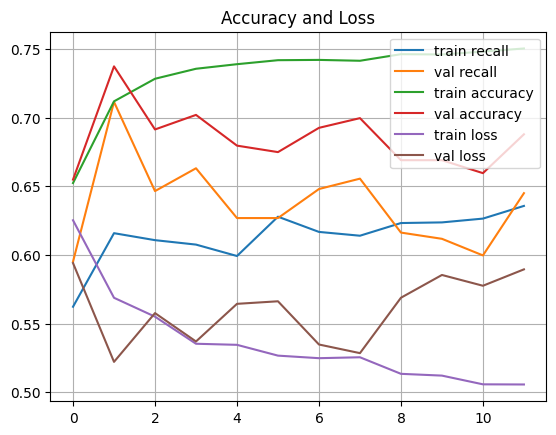

In [63]:
# Accuracies and losses
plt.plot(history.history['recall'], label='train recall')
plt.plot(history.history['val_recall'], label='val recall')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.title('Accuracy and Loss')
plt.show()

The training and validation curves in the plot indicate that the model is learning effectively, with both training and validation accuracy steadily improving and converging around 0.72. The training and validation loss curves also show expected behavior, with the training loss decreasing smoothly and validation loss initially dropping before slightly rising, suggesting a mild risk of overfitting after around 20 epochs. The recall on the training set gradually improves, indicating the model is increasingly successful at identifying malnourished children during training. However, the validation recall fluctuates significantly across epochs, which may point to model adjustments.

In [64]:
y_pred = (ann_base.predict(X_test) > 0.5).astype("int")
print(classification_report(y_test, y_pred, digits=3))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0      0.761     0.774     0.767       707
           1      0.718     0.703     0.710       579

    accuracy                          0.742      1286
   macro avg      0.739     0.738     0.739      1286
weighted avg      0.741     0.742     0.742      1286



2025-07-15 00:11:48.986474: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [65]:
# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_pred)}')

Average Precision: 0.6383247603339806


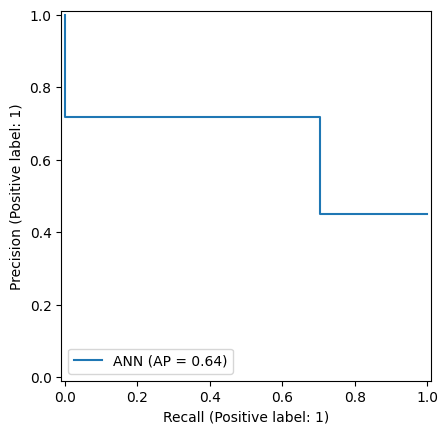

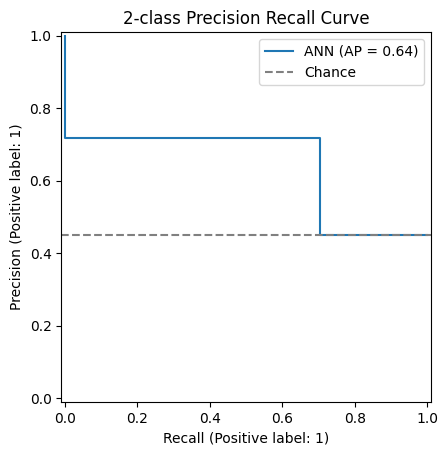

In [66]:
# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

# Hyperparameter Tuning

In [67]:
# Define a model builder function
def build_model(hp):
    ann = Sequential()

    # Add input layer
    ann.add(Input(shape=(X_train_sm.shape[1],)))

    # First dense layer: tune number of neurons and dropout
    ann.add(Dense(
        hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))

    # Second dense layer
    ann.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Output layer
    ann.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    ann.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )

    return ann

In [68]:
# Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),  # Focus on recall
    max_trials=5,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='malnutrition_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the search
tuner.search(
    X_train_sm, y_train_sm,
    validation_split=0.15,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 00m 15s]
val_recall: 0.731117844581604

Best val_recall So Far: 0.731117844581604
Total elapsed time: 00h 01m 25s


In [69]:
ann_tuned = tuner.get_best_models(1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

# Re-compile the best model before using it
ann_tuned.compile(
    optimizer=Adam(learning_rate=best_hps.get('learning_rate')),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall()]
)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [70]:

# Evaluate or predict
y_pred_tuned = (ann_tuned.predict(X_test) > 0.5).astype("int")
print("Classification Report:\n", classification_report(y_test, y_pred_tuned, digits=3))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


2025-07-15 00:13:36.830268: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Classification Report:
               precision    recall  f1-score   support

           0      0.748     0.696     0.721       707
           1      0.658     0.713     0.684       579

    accuracy                          0.704      1286
   macro avg      0.703     0.705     0.703      1286
weighted avg      0.707     0.704     0.704      1286



In [71]:
print("Best Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

Best Hyperparameters:
units_1: 96
dropout_1: 0.4
units_2: 32
dropout_2: 0.1
learning_rate: 0.0005


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step


2025-07-15 00:14:30.394482: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


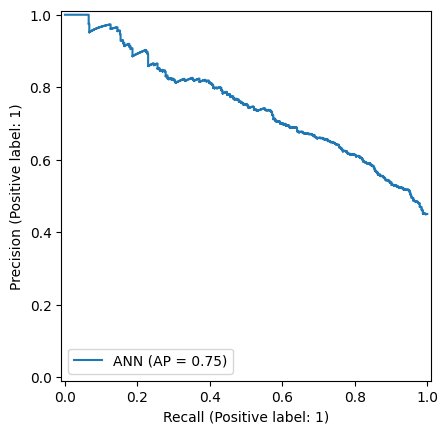

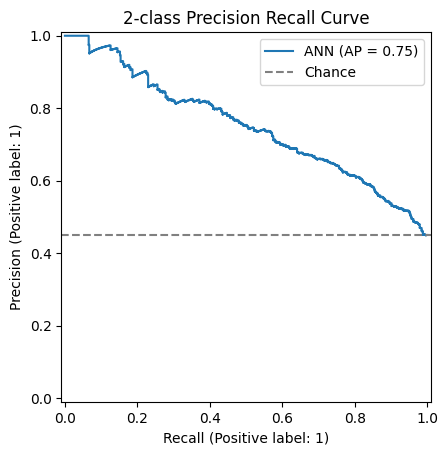

In [74]:
# Get predicted probabilities
y_probas = ann_tuned.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


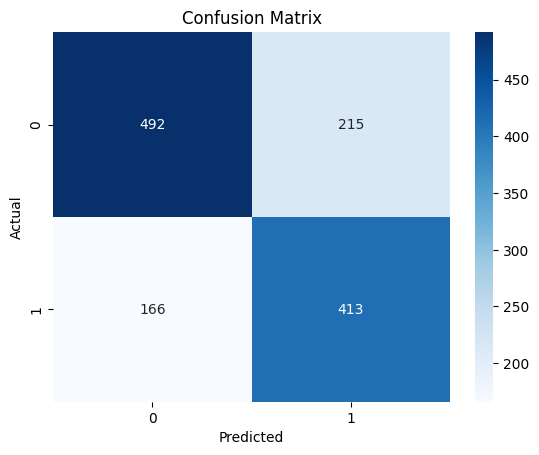

In [54]:
# Predict classes
y_prob = ann_tuned.predict(X_test)
# y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [55]:
explainer = shap.Explainer(ann_tuned.predict, X_train_sm)
shap_values = explainer(X_test[:100])  # Subset for speed

# Summary plot
shap.summary_plot(shap_values, X_test[:100])


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step
46/46 ━━━━━━━━━━━━━━━━━━━

2025-07-15 00:07:56.246776: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
43/43 ━━━━━━━━━━━━━━

2025-07-15 00:08:01.357344: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step


...

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step


PermutationExplainer explainer:  99%|█████████▉| 99/100 [03:09<00:01,  1.92s/it]

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


PermutationExplainer explainer:  99%|█████████▉| 99/100 [03:09<00:02,  2.04s/it]


KeyboardInterrupt: 

### Additional

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


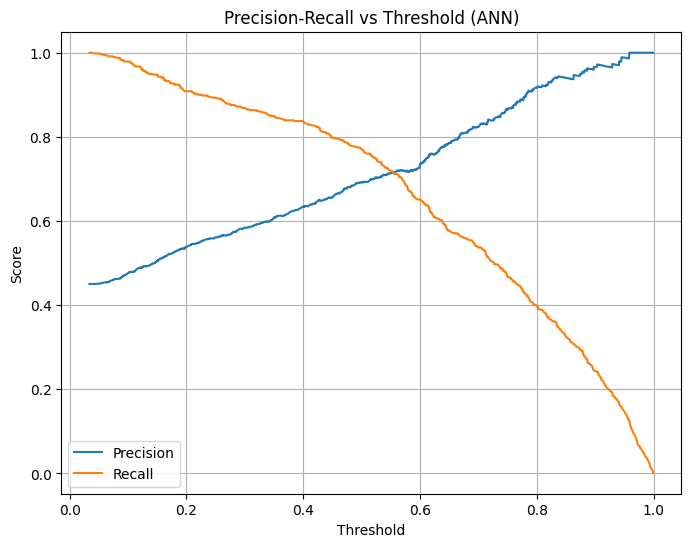

In [ ]:
# Get predicted probabilities from Keras model
y_probas = ann_tuned.predict(X_test).flatten()

# Precision-Recall calculation
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (ANN)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.82      0.60      0.70       707
           1       0.63      0.84      0.72       579

    accuracy                           0.71      1286
   macro avg       0.73      0.72      0.71      1286
weighted avg       0.74      0.71      0.71      1286


